# V2 Experiment — Reranker Comparison: Mistral vs Cross-Encoder

## Goal
Find the best reranker for the final chatbot by comparing:

| | Mistral Large (LLM Reranker) | Cross-Encoder (ms-marco-MiniLM) |
|---|---|---|
| Type | LLM scoring via OpenRouter | Local bi-stage cross-encoder |
| Speed | ~2-5s per query (API) | ~0.1s per query (local) |
| Cost | OpenRouter credits | Free |

## Pipeline (same for both)
```
Query → Fine-Tuned MiniLM → FAISS Top-20 → [Reranker] → Top-3 → Evaluate
```

## Dataset
- **200 queries** stratified sample from the held-out 20% eval set (training_pairs.csv)
- **Full S4 corpus** (~14k chunks from 41 PDFs) as the retrieval pool
- Same split as fine-tuning (random_state=42, stratify=category) — fair evaluation

## Metrics
- **NDCG@10** — primary ranking quality
- **MRR@10** — how high the first correct result appears
- **Recall@3** — % correct chunks found in top-3 after reranking
- **Speed** — seconds per query

In [2]:
# ── Cell 1: Setup & Paths ──────────────────────────────────────────────────────
import sys, os
from pathlib import Path

def find_repo_root(start=None):
    p = Path(start or os.getcwd()).resolve()
    for parent in [p] + list(p.parents):
        if (parent / 'config.py').exists():
            return parent
    raise FileNotFoundError('config.py not found')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

FINE_TUNE_DIR   = REPO_ROOT / 'fine_tuning'
FINAL_CHAT_DIR  = REPO_ROOT / 'final_chatbot'
RESULTS_DIR     = FINAL_CHAT_DIR / 'experiment_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

S4_CORPUS_PATH  = FINE_TUNE_DIR / 's4_corpus.csv'
PAIRS_PATH      = FINE_TUNE_DIR / 'training_pairs.csv'
FT_MODEL_PATH   = str(FINE_TUNE_DIR / 'minilm_finetuned')

assert os.path.exists(S4_CORPUS_PATH), f'MISSING: {S4_CORPUS_PATH}'
assert os.path.exists(PAIRS_PATH),     f'MISSING: {PAIRS_PATH}'
assert os.path.exists(FT_MODEL_PATH),  f'MISSING: {FT_MODEL_PATH}'

print(f'Repo root   : {REPO_ROOT}')
print(f'Results dir : {RESULTS_DIR}')
print('Paths OK')

Repo root   : /Users/momo/Desktop/GEN AI/Finsearch Project/FinSearch_Intent_Aware_Financial_Document_Intelligence-
Results dir : /Users/momo/Desktop/GEN AI/Finsearch Project/FinSearch_Intent_Aware_Financial_Document_Intelligence-/final_chatbot/experiment_results
Paths OK


In [3]:
# ── Cell 2: Install ────────────────────────────────────────────────────────────
import sys
!{sys.executable} -m pip install -q sentence-transformers faiss-cpu openai python-dotenv scikit-learn tqdm

In [4]:
# ── Cell 3: Imports ────────────────────────────────────────────────────────────
import json, time, random
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer, CrossEncoder

# Load API key (override=True forces .env over shell)
load_dotenv(REPO_ROOT / '.env', override=True)
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY')
assert OPENROUTER_API_KEY, 'OPENROUTER_API_KEY not found in .env'

client = OpenAI(
    api_key=OPENROUTER_API_KEY,
    base_url='https://openrouter.ai/api/v1'
)

MISTRAL_MODEL = 'mistralai/mistral-large-2411'
CE_MODEL      = 'cross-encoder/ms-marco-MiniLM-L-6-v2'

print('Imports OK')
print(f'OpenRouter key: ...{OPENROUTER_API_KEY[-6:]}')
print(f'Mistral model : {MISTRAL_MODEL}')
print(f'CE model      : {CE_MODEL}')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK
OpenRouter key: ...c27214
Mistral model : mistralai/mistral-large-2411
CE model      : cross-encoder/ms-marco-MiniLM-L-6-v2


## Cell 4 — Load Data & Build 200-Query Eval Set

We use the **exact same 20% held-out split** as fine-tuning (random_state=42, stratify=category),
then stratified-sample 200 queries from it for a concise, fair experiment.

In [5]:
# ── Cell 4: Load Data ──────────────────────────────────────────────────────────
corpus_df = pd.read_csv(S4_CORPUS_PATH)
pairs_df  = pd.read_csv(PAIRS_PATH)

print(f'S4 corpus : {len(corpus_df):,} chunks')
print(f'All pairs : {len(pairs_df):,}')

# ── Same split as fine-tuning ──────────────────────────────────────────────────
_, eval_df = train_test_split(
    pairs_df,
    test_size=0.20,
    random_state=42,
    stratify=pairs_df['category']
)
eval_df = eval_df.reset_index(drop=True)
print(f'\nFull eval set : {len(eval_df):,} pairs (20% held-out)')

# ── Stratified sample of 200 queries for this experiment ──────────────────────
SAMPLE_SIZE = 200
sample_df, _ = train_test_split(
    eval_df,
    train_size=SAMPLE_SIZE,
    random_state=42,
    stratify=eval_df['category']
)
sample_df = sample_df.reset_index(drop=True)

print(f'Experiment set: {len(sample_df):,} queries (stratified sample)')
print(f'\nPer-category:')
print(sample_df['category'].value_counts().to_string())

# ── Build corpus lookup ────────────────────────────────────────────────────────
corpus_texts = corpus_df['text'].tolist()
corpus_ids   = corpus_df['chunk_id'].tolist()
id_to_text   = dict(zip(corpus_ids, corpus_texts))

print(f'\nCorpus pool : {len(corpus_texts):,} chunks')

S4 corpus : 14,502 chunks
All pairs : 17,682

Full eval set : 3,537 pairs (20% held-out)
Experiment set: 200 queries (stratified sample)

Per-category:
category
Regulatory             90
Payment_Industry       59
Consumer_Protection    28
Synthetic_Policies     23

Corpus pool : 14,502 chunks


## Cell 5 — Build FAISS Index with Fine-Tuned MiniLM

Encode all 14k+ corpus chunks once. Both rerankers share the same Top-20 retrieval results.

In [6]:
# ── Cell 5: FAISS Index ────────────────────────────────────────────────────────
TOP_K = 20   # retrieve top-20, then reranker selects top-3

print('Loading fine-tuned MiniLM...')
ft_model = SentenceTransformer(FT_MODEL_PATH)

print(f'Encoding {len(corpus_texts):,} corpus chunks...')
corpus_embs = ft_model.encode(
    corpus_texts,
    batch_size=256,
    normalize_embeddings=True,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype(np.float32)

index = faiss.IndexFlatIP(corpus_embs.shape[1])
index.add(corpus_embs)

print(f'\nFAISS index ready: {index.ntotal:,} vectors')

# ── Encode all 200 queries ─────────────────────────────────────────────────────
print(f'Encoding {len(sample_df):,} queries...')
query_embs = ft_model.encode(
    sample_df['question'].tolist(),
    batch_size=128,
    normalize_embeddings=True,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype(np.float32)

# ── Retrieve Top-20 for each query ────────────────────────────────────────────
scores_matrix, indices_matrix = index.search(query_embs, TOP_K)

# Store candidates per query: list of (chunk_id, chunk_text, retrieval_score)
candidates = []
for i in range(len(sample_df)):
    cands = []
    for rank, (idx, score) in enumerate(zip(indices_matrix[i], scores_matrix[i])):
        cands.append({
            'chunk_id'   : corpus_ids[idx],
            'text'       : corpus_texts[idx],
            'ret_score'  : float(score),
            'ret_rank'   : rank + 1,
        })
    candidates.append(cands)

print(f'\nTop-{TOP_K} candidates retrieved for all {len(sample_df)} queries')
print('Ready for reranking.')

Loading fine-tuned MiniLM...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 14131.01it/s]


Encoding 14,502 corpus chunks...


Batches: 100%|██████████| 57/57 [01:07<00:00,  1.18s/it]



FAISS index ready: 14,502 vectors
Encoding 200 queries...


Batches: 100%|██████████| 2/2 [00:00<00:00,  7.20it/s]


Top-20 candidates retrieved for all 200 queries
Ready for reranking.


## Cell 6 — Define Rerankers

**Reranker A — Mistral Large (LLM)**  
Sends each (query, chunk) pair to Mistral with a scoring prompt. Returns a relevance score 1-10.

**Reranker B — Cross-Encoder (ms-marco-MiniLM-L-6-v2)**  
Local model. Scores (query, chunk) pairs directly — no API needed.

In [7]:
# ── Cell 6: Define Rerankers ───────────────────────────────────────────────────

# ── Reranker A: Mistral Large ──────────────────────────────────────────────────
MISTRAL_PROMPT = """You are a financial document relevance scorer.
Score how relevant the passage is to the query on a scale of 1 to 10.
Reply with ONLY a single integer (1-10). No explanation.

Query: {query}
Passage: {passage}
Score:"""

def mistral_score_batch(query, chunks, retry=2):
    """Score a list of chunks for a query using Mistral. Returns list of floats."""
    scores = []
    for chunk in chunks:
        prompt = MISTRAL_PROMPT.format(
            query=query,
            passage=chunk['text'][:800]   # truncate to save tokens
        )
        for attempt in range(retry + 1):
            try:
                resp = client.chat.completions.create(
                    model=MISTRAL_MODEL,
                    messages=[{'role': 'user', 'content': prompt}],
                    max_tokens=3,
                    temperature=0.0,
                )
                raw = resp.choices[0].message.content.strip()
                score = float(raw.split()[0])
                scores.append(min(max(score, 1.0), 10.0))
                break
            except Exception as e:
                if attempt == retry:
                    scores.append(chunk['ret_score'] * 10)  # fallback to retrieval score
                time.sleep(1)
    return scores


# ── Reranker B: Cross-Encoder ──────────────────────────────────────────────────
print(f'Loading Cross-Encoder: {CE_MODEL}...')
ce_model = CrossEncoder(CE_MODEL, max_length=512)
print('Cross-Encoder loaded.')

def ce_score_batch(query, chunks):
    """Score chunks using Cross-Encoder. Returns list of floats."""
    pairs = [(query, chunk['text']) for chunk in chunks]
    return ce_model.predict(pairs).tolist()


print('\nBoth rerankers defined and ready.')

Loading Cross-Encoder: cross-encoder/ms-marco-MiniLM-L-6-v2...


Loading weights: 100%|██████████| 105/105 [00:00<00:00, 8718.76it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Cross-Encoder loaded.

Both rerankers defined and ready.


## Cell 7 — Evaluation Helpers

NDCG@k, MRR@k, Recall@k computed from ranked results.

In [10]:
# ── Cell 7: Evaluation Helpers ─────────────────────────────────────────────────

def ndcg_at_k(ranked_ids, relevant_ids, k=10):
    dcg, ideal_dcg = 0.0, 0.0
    for i, cid in enumerate(ranked_ids[:k]):
        rel = 1 if cid in relevant_ids else 0
        dcg += rel / np.log2(i + 2)
    for i in range(min(len(relevant_ids), k)):
        ideal_dcg += 1.0 / np.log2(i + 2)
    return dcg / ideal_dcg if ideal_dcg > 0 else 0.0

def mrr_at_k(ranked_ids, relevant_ids, k=10):
    for i, cid in enumerate(ranked_ids[:k]):
        if cid in relevant_ids:
            return 1.0 / (i + 1)
    return 0.0

def recall_at_k(ranked_ids, relevant_ids, k=3):
    hits = sum(1 for cid in ranked_ids[:k] if cid in relevant_ids)
    return hits / len(relevant_ids) if relevant_ids else 0.0

def evaluate_results(all_ranked_ids, all_relevant_ids):
    """Compute mean metrics over all queries."""
    ndcgs, mrrs, recalls = [], [], []
    for ranked, relevant in zip(all_ranked_ids, all_relevant_ids):
        ndcgs.append(ndcg_at_k(ranked, relevant, k=10))
        mrrs.append(mrr_at_k(ranked, relevant, k=10))
        recalls.append(recall_at_k(ranked, relevant, k=3))
    return {
        'NDCG@10'  : round(float(np.mean(ndcgs)),   4),
        'MRR@10'   : round(float(np.mean(mrrs)),    4),
        'Recall@3' : round(float(np.mean(recalls)), 4),
    }

# Ground truth relevant chunk_ids per query
ground_truth = [{ row['chunk_id'] } for _, row in sample_df.iterrows()]

print('Evaluation helpers defined.')
print(f'Ground truth ready for {len(ground_truth)} queries.')

Evaluation helpers defined.
Ground truth ready for 200 queries.


## Cell 8 — Baseline: Fine-Tuned MiniLM (No Reranking)

Measures FAISS retrieval quality alone — the floor both rerankers must beat.

In [11]:
# ── Cell 8: Baseline (No Reranker) ────────────────────────────────────────────
baseline_ranked = [
    [c['chunk_id'] for c in cands]
    for cands in candidates
]

baseline_metrics = evaluate_results(baseline_ranked, ground_truth)
baseline_metrics['Speed_s_per_query'] = 0.0   # already encoded above

print('Baseline — Fine-Tuned MiniLM (No Reranker):')
for k, v in baseline_metrics.items():
    print(f'  {k:<20} {v}')

Baseline — Fine-Tuned MiniLM (No Reranker):
  NDCG@10              0.7381
  MRR@10               0.6889
  Recall@3             0.77
  Speed_s_per_query    0.0


## Cell 9 — Query Expansion (LLaMA 3.3 70B)\n\nExpands each query with financial synonyms and related terms before retrieval.\nCost: ~$0.02 for 200 queries (LLaMA is very cheap vs Mistral).\n\n**Example:**\n```\nOriginal : \"capital requirements\"\nExpanded : \"capital requirements minimum CET1 ratio Basel III Tier 1 equity buffer adequacy\"\n```"

In [8]:
# ── Cell 9: Query Expansion ────────────────────────────────────────────────────
LLAMA_MODEL = 'meta-llama/llama-3.3-70b-instruct'

QE_PROMPT = """You are a financial search expert. Expand the query below with relevant financial terms, synonyms, and related concepts to improve document retrieval accuracy.
Return ONLY the expanded query as a single line. No explanation, no bullet points.

Original query: {query}
Expanded query:"""

def expand_query(query, retry=2):
    """Expand a query using LLaMA. Falls back to original on failure."""
    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=LLAMA_MODEL,
                messages=[{'role': 'user', 'content': QE_PROMPT.format(query=query)}],
                max_tokens=100,
                temperature=0.3,
            )
            expanded = resp.choices[0].message.content.strip()
            # Safety: if response is too long or empty, fall back
            if not expanded or len(expanded) > 500:
                return query
            return expanded
        except Exception:
            if attempt == retry:
                return query   # fallback to original query
            time.sleep(1)

# ── Generate expanded queries for all 200 queries ─────────────────────────────
print(f'Expanding {len(sample_df)} queries with LLaMA...')
expanded_queries = []
for i, row in enumerate(tqdm(sample_df.itertuples(), total=len(sample_df), desc='Query Expansion')):
    expanded_queries.append(expand_query(row.question))

# Show a few examples
print('\nSample expansions:')
for i in range(3):
    print(f'\n  Original : {sample_df.iloc[i]["question"]}')
    print(f'  Expanded : {expanded_queries[i]}')

# ── Encode expanded queries + retrieve Top-20 ──────────────────────────────────
print(f'\nEncoding {len(expanded_queries)} expanded queries...')
qe_embs = ft_model.encode(
    expanded_queries,
    batch_size=128,
    normalize_embeddings=True,
    show_progress_bar=True,
    convert_to_numpy=True,
).astype(np.float32)

qe_scores_matrix, qe_indices_matrix = index.search(qe_embs, TOP_K)

# Build QE candidates list (same structure as original candidates)
qe_candidates = []
for i in range(len(sample_df)):
    cands = []
    for rank, (idx, score) in enumerate(zip(qe_indices_matrix[i], qe_scores_matrix[i])):
        cands.append({
            'chunk_id'  : corpus_ids[idx],
            'text'      : corpus_texts[idx],
            'ret_score' : float(score),
            'ret_rank'  : rank + 1,
        })
    qe_candidates.append(cands)

print(f'\nQE retrieval done. Top-{TOP_K} candidates ready for all {len(sample_df)} queries.')

Expanding 200 queries with LLaMA...


Query Expansion: 100%|██████████| 200/200 [10:53<00:00,  3.27s/it]



Sample expansions:

  Original : What exception under 1026.35(b)(2)(iii)(d)(2) does a creditor not qualify for if it establishes escrow accounts after consummation as a regular business practice?
  Expanded : What exception under 1026.35(b)(2)(iii)(d)(2) Regulation Z, Truth in Lending Act, TILA, consumer credit, escrow account, escrow waiver, mortgage lending, loan origination, post-consummation, regular business practice, creditor exemption, finance charge, interest rate, loan terms does a creditor, lender, financial institution not qualify for if it establishes escrow accounts after loan closing, settlement, consummation as a standard practice, usual

  Original : What specific sections of 1026 are exempt from written disclosure requirements under an open-end, non-home-secured plan?
  Expanded : What specific sections of Regulation Z 1026 are exempt from written disclosure requirements under an open-end non-home-secured credit plan or loan including consumer credit transactions exem

Batches: 100%|██████████| 2/2 [00:00<00:00,  2.32it/s]


QE retrieval done. Top-20 candidates ready for all 200 queries.


In [12]:
# ── Cell 9b: Baseline + QE (No Reranker) ──────────────────────────────────────
qe_baseline_ranked = [
    [c['chunk_id'] for c in cands]
    for cands in qe_candidates
]

qe_baseline_metrics = evaluate_results(qe_baseline_ranked, ground_truth)
qe_baseline_metrics['Speed_s_per_query'] = 0.0

print('Baseline + QE (No Reranker):')
for k, v in qe_baseline_metrics.items():
    print(f'  {k:<20} {v}')

delta_ndcg = qe_baseline_metrics['NDCG@10'] - baseline_metrics['NDCG@10']
print(f'\nQE delta vs no-QE baseline: {delta_ndcg:+.4f} NDCG@10')

Baseline + QE (No Reranker):
  NDCG@10              0.6439
  MRR@10               0.5926
  Recall@3             0.665
  Speed_s_per_query    0.0

QE delta vs no-QE baseline: -0.0942 NDCG@10


## Cell 9 — Run Cross-Encoder Reranker

Local model — fast, free. Scores all Top-20 candidates and picks Top-3.

In [13]:
# ── Cell 9: Cross-Encoder Reranking ───────────────────────────────────────────
ce_ranked_ids = []
ce_times      = []

for i, (row, cands) in enumerate(tqdm(zip(sample_df.itertuples(), candidates),
                                      total=len(sample_df),
                                      desc='Cross-Encoder')):
    t0     = time.time()
    scores = ce_score_batch(row.question, cands)
    elapsed = time.time() - t0

    reranked = sorted(zip(scores, cands), key=lambda x: x[0], reverse=True)
    ce_ranked_ids.append([c['chunk_id'] for _, c in reranked])
    ce_times.append(elapsed)

ce_metrics = evaluate_results(ce_ranked_ids, ground_truth)
ce_metrics['Speed_s_per_query'] = round(float(np.mean(ce_times)), 4)

print('\nCross-Encoder Reranker results:')
for k, v in ce_metrics.items():
    print(f'  {k:<20} {v}')

Cross-Encoder: 100%|██████████| 200/200 [00:25<00:00,  7.86it/s]


Cross-Encoder Reranker results:
  NDCG@10              0.7423
  MRR@10               0.696
  Recall@3             0.79
  Speed_s_per_query    0.1266


In [14]:
# ── Cell 10b: Cross-Encoder + QE ──────────────────────────────────────────────
qe_ce_ranked_ids = []
qe_ce_times      = []

for i, (row, cands) in enumerate(tqdm(zip(sample_df.itertuples(), qe_candidates),
                                      total=len(sample_df),
                                      desc='Cross-Encoder + QE')):
    t0     = time.time()
    # Use expanded query for CE scoring
    scores = ce_model.predict([(expanded_queries[i], c['text']) for c in cands]).tolist()
    elapsed = time.time() - t0

    reranked = sorted(zip(scores, cands), key=lambda x: x[0], reverse=True)
    qe_ce_ranked_ids.append([c['chunk_id'] for _, c in reranked])
    qe_ce_times.append(elapsed)

qe_ce_metrics = evaluate_results(qe_ce_ranked_ids, ground_truth)
qe_ce_metrics['Speed_s_per_query'] = round(float(np.mean(qe_ce_times)), 4)

print('Cross-Encoder + QE results:')
for k, v in qe_ce_metrics.items():
    print(f'  {k:<20} {v}')

delta = qe_ce_metrics['NDCG@10'] - ce_metrics['NDCG@10']
print(f'\nQE delta vs CE-only: {delta:+.4f} NDCG@10')

Cross-Encoder + QE: 100%|██████████| 200/200 [00:30<00:00,  6.48it/s]

Cross-Encoder + QE results:
  NDCG@10              0.6367
  MRR@10               0.5848
  Recall@3             0.655
  Speed_s_per_query    0.1536

QE delta vs CE-only: -0.1056 NDCG@10


## Cell 10 — Run Mistral Reranker (Listwise)\n\nSends all Top-20 chunks in **1 API call per query** and asks Mistral to rank them.

In [18]:
# ── Cell 10: Mistral Reranking (Listwise) ─────────────────────────────────────
# Sends all 20 chunks in ONE API call per query.
# Mistral returns a ranked list of indices → we reorder candidates accordingly.

LISTWISE_PROMPT = """You are a financial document relevance expert.
Given a query and {n} candidate passages, rank them by relevance to the query.
Return ONLY a JSON array of indices (0-based) from most to least relevant.
Example for 5 passages: [2, 0, 4, 1, 3]

Query: {query}

Passages:
{passages}

Ranked indices (JSON array only):"""

def mistral_listwise(query, cands, retry=2):
    """Rank all candidates in one Mistral call. Returns reordered candidates list."""
    n = len(cands)
    passages_str = '\n'.join(
        f'[{i}] {c["text"][:400]}'   # 400 chars per chunk to fit context
        for i, c in enumerate(cands)
    )
    prompt = LISTWISE_PROMPT.format(n=n, query=query, passages=passages_str)

    for attempt in range(retry + 1):
        try:
            resp = client.chat.completions.create(
                model=MISTRAL_MODEL,
                messages=[{'role': 'user', 'content': prompt}],
                max_tokens=80,
                temperature=0.0,
            )
            raw = resp.choices[0].message.content.strip()

            # Parse JSON array from response
            import re
            match = re.search(r'\[[\d,\s]+\]', raw)
            if not match:
                raise ValueError(f'No JSON array in response: {raw}')
            ranked_indices = json.loads(match.group())

            # Reorder candidates; append any missing indices at the end
            seen = set()
            reranked = []
            for idx in ranked_indices:
                if isinstance(idx, int) and 0 <= idx < n and idx not in seen:
                    reranked.append(cands[idx])
                    seen.add(idx)
            # Append any candidates Mistral missed
            for idx in range(n):
                if idx not in seen:
                    reranked.append(cands[idx])
            return reranked

        except Exception as e:
            if attempt == retry:
                return cands   # fallback: original retrieval order
            time.sleep(1)

# ── Run Mistral on all 200 queries ────────────────────────────────────────────
mistral_ranked_ids = []
mistral_times      = []

for i, (row, cands) in enumerate(tqdm(zip(sample_df.itertuples(), candidates),
                                      total=len(sample_df),
                                      desc='Mistral Listwise')):
    t0       = time.time()
    reranked = mistral_listwise(row.question, cands)
    elapsed  = time.time() - t0

    mistral_ranked_ids.append([c['chunk_id'] for c in reranked])
    mistral_times.append(elapsed)

    if (i + 1) % 50 == 0:
        partial  = evaluate_results(mistral_ranked_ids, ground_truth[:i+1])
        avg_t    = np.mean(mistral_times)
        eta_min  = (len(sample_df) - i - 1) * avg_t / 60
        print(f'  [{i+1}/{len(sample_df)}] NDCG@10={partial["NDCG@10"]:.4f}  '
              f'MRR={partial["MRR@10"]:.4f}  ETA: {eta_min:.1f} min')

mistral_metrics = evaluate_results(mistral_ranked_ids, ground_truth)
mistral_metrics['Speed_s_per_query'] = round(float(np.mean(mistral_times)), 4)

print('\nMistral Listwise Reranker results:')
for k, v in mistral_metrics.items():
    print(f'  {k:<20} {v}')

Mistral Listwise:  25%|██▌       | 50/200 [02:07<05:38,  2.26s/it]

  [50/200] NDCG@10=0.7138  MRR=0.6469  ETA: 6.4 min


Mistral Listwise:  50%|█████     | 100/200 [04:16<03:18,  1.98s/it]

  [100/200] NDCG@10=0.6517  MRR=0.5915  ETA: 4.3 min


Mistral Listwise:  75%|███████▌  | 150/200 [07:09<02:13,  2.67s/it]

  [150/200] NDCG@10=0.6446  MRR=0.5850  ETA: 2.4 min


Mistral Listwise: 100%|██████████| 200/200 [09:26<00:00,  2.83s/it]

  [200/200] NDCG@10=0.6206  MRR=0.5593  ETA: 0.0 min

Mistral Listwise Reranker results:
  NDCG@10              0.6206
  MRR@10               0.5593
  Recall@3             0.635
  Speed_s_per_query    2.8318


In [ ]:
# ── Cell 11b: Mistral + QE ────────────────────────────────────────────────────
qe_mistral_ranked_ids = []
qe_mistral_times      = []

for i, (row, cands) in enumerate(tqdm(zip(sample_df.itertuples(), qe_candidates),
                                      total=len(sample_df),
                                      desc='Mistral + QE')):
    t0       = time.time()
    # Use expanded query for Mistral listwise ranking
    reranked = mistral_listwise(expanded_queries[i], cands)
    elapsed  = time.time() - t0

    qe_mistral_ranked_ids.append([c['chunk_id'] for c in reranked])
    qe_mistral_times.append(elapsed)

    if (i + 1) % 50 == 0:
        partial = evaluate_results(qe_mistral_ranked_ids, ground_truth[:i+1])
        avg_t   = np.mean(qe_mistral_times)
        eta_min = (len(sample_df) - i - 1) * avg_t / 60
        print(f'  [{i+1}/{len(sample_df)}] NDCG@10={partial["NDCG@10"]:.4f}  '
              f'MRR={partial["MRR@10"]:.4f}  ETA: {eta_min:.1f} min')

qe_mistral_metrics = evaluate_results(qe_mistral_ranked_ids, ground_truth)
qe_mistral_metrics['Speed_s_per_query'] = round(float(np.mean(qe_mistral_times)), 4)

print('\nMistral + QE results:')
for k, v in qe_mistral_metrics.items():
    print(f'  {k:<20} {v}')



Mistral + QE:  25%|██▌       | 50/200 [02:39<05:40,  2.27s/it]

  [50/200] NDCG@10=0.6100  MRR=0.5510  ETA: 8.0 min


Mistral + QE:  50%|█████     | 100/200 [04:52<04:14,  2.55s/it]

  [100/200] NDCG@10=0.6162  MRR=0.5551  ETA: 4.9 min


Mistral + QE:  75%|███████▌  | 150/200 [07:31<01:55,  2.32s/it]

  [150/200] NDCG@10=0.6023  MRR=0.5459  ETA: 2.5 min


Mistral + QE: 100%|██████████| 200/200 [10:31<00:00,  3.16s/it]

  [200/200] NDCG@10=0.5887  MRR=0.5335  ETA: 0.0 min

Mistral + QE results:
  NDCG@10              0.5887
  MRR@10               0.5335
  Recall@3             0.6
  Speed_s_per_query    3.1569


NameError: name 'mistral_metrics' is not defined

In [19]:
delta = qe_mistral_metrics['NDCG@10'] - mistral_metrics['NDCG@10']
print(f'\nQE delta vs Mistral-only: {delta:+.4f} NDCG@10')


QE delta vs Mistral-only: -0.0319 NDCG@10


## Cell 11 — Compare & Declare Winner

In [20]:
# ── Cell 12: Full Comparison Table ────────────────────────────────────────────
pipelines = {
    'No Reranker'       : baseline_metrics,
    'No Reranker + QE'  : qe_baseline_metrics,
    'Cross-Encoder'     : ce_metrics,
    'CE + QE'           : qe_ce_metrics,
    'Mistral'           : mistral_metrics,
    'Mistral + QE'      : qe_mistral_metrics,
}

metrics_keys = ['NDCG@10', 'MRR@10', 'Recall@3', 'Speed_s_per_query']

print('=' * 95)
header = f'  {"Metric":<22}' + ''.join(f'{name:>15}' for name in pipelines)
print(header)
print('=' * 95)
for m in metrics_keys:
    row = f'  {m:<22}' + ''.join(f'{pipelines[name].get(m, 0):>15.4f}' for name in pipelines)
    print(row)
print('=' * 95)

# Winner by NDCG@10 (excluding speed)
quality_pipelines = {k: v['NDCG@10'] for k, v in pipelines.items()}
winner = max(quality_pipelines, key=quality_pipelines.get)
best_score = quality_pipelines[winner]

print(f'\nWinner (NDCG@10): {winner}  →  {best_score:.4f}')

# QE impact summary
print('\nQE Impact:')
print(f'  No Reranker : {baseline_metrics["NDCG@10"]:.4f} → {qe_baseline_metrics["NDCG@10"]:.4f}  ({qe_baseline_metrics["NDCG@10"]-baseline_metrics["NDCG@10"]:+.4f})')
print(f'  Cross-Encoder: {ce_metrics["NDCG@10"]:.4f} → {qe_ce_metrics["NDCG@10"]:.4f}  ({qe_ce_metrics["NDCG@10"]-ce_metrics["NDCG@10"]:+.4f})')
print(f'  Mistral      : {mistral_metrics["NDCG@10"]:.4f} → {qe_mistral_metrics["NDCG@10"]:.4f}  ({qe_mistral_metrics["NDCG@10"]-mistral_metrics["NDCG@10"]:+.4f})')

# Save full results
output = {
    'experiment'  : 'Reranker + QE Comparison (6 Pipelines)',
    'dataset'     : f'{len(sample_df)} stratified queries from S4 eval set',
    'retriever'   : 'Fine-Tuned MiniLM (FAISS Top-20)',
    'winner'      : winner,
    'pipelines'   : {k: v for k, v in pipelines.items()},
}
out_path = RESULTS_DIR / 'reranker_qe_comparison.json'
with open(out_path, 'w') as f:
    json.dump(output, f, indent=2)
print(f'\nFull results saved to: {out_path}')

  Metric                    No RerankerNo Reranker + QE  Cross-Encoder        CE + QE        Mistral   Mistral + QE
  NDCG@10                        0.7381         0.6439         0.7423         0.6367         0.6206         0.5887
  MRR@10                         0.6889         0.5926         0.6960         0.5848         0.5593         0.5335
  Recall@3                       0.7700         0.6650         0.7900         0.6550         0.6350         0.6000
  Speed_s_per_query              0.0000         0.0000         0.1266         0.1536         2.8318         3.1569

Winner (NDCG@10): Cross-Encoder  →  0.7423

QE Impact:
  No Reranker : 0.7381 → 0.6439  (-0.0942)
  Cross-Encoder: 0.7423 → 0.6367  (-0.1056)
  Mistral      : 0.6206 → 0.5887  (-0.0319)

Full results saved to: /Users/momo/Desktop/GEN AI/Finsearch Project/FinSearch_Intent_Aware_Financial_Document_Intelligence-/final_chatbot/experiment_results/reranker_qe_comparison.json


## Cell 12 — Visualise Results

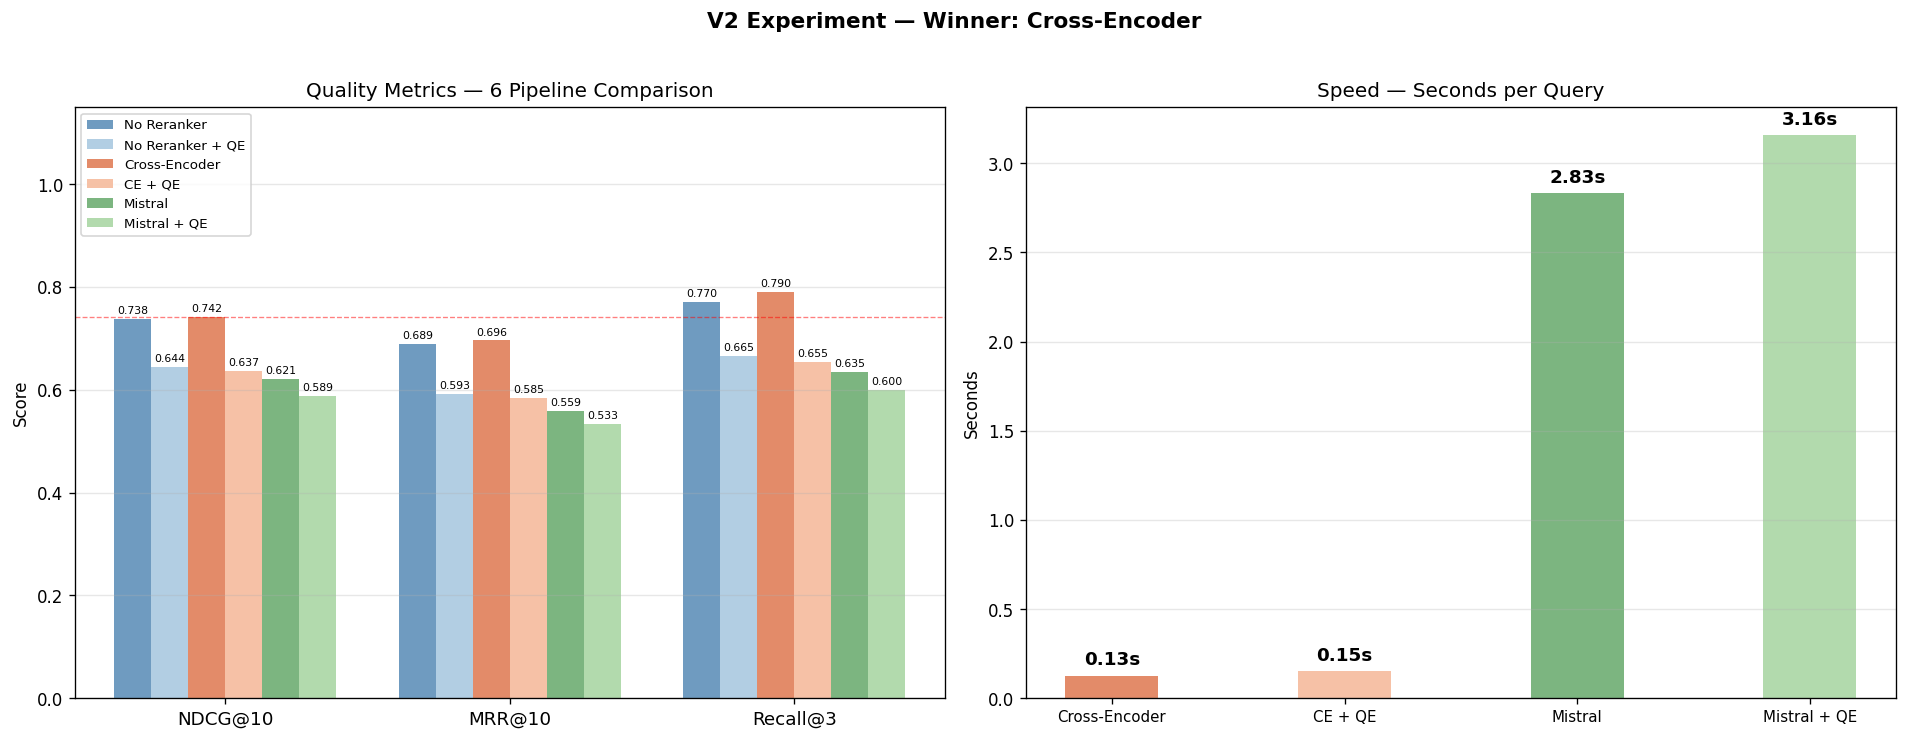

Chart saved to: /Users/momo/Desktop/GEN AI/Finsearch Project/FinSearch_Intent_Aware_Financial_Document_Intelligence-/final_chatbot/experiment_results/reranker_qe_comparison.png

Final winner for chatbot: Cross-Encoder


In [21]:
# ── Cell 13: Visualise All 6 Pipelines ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pipeline_names  = list(pipelines.keys())
colors = ['#5B8DB8', '#A8C8E0', '#E07B54', '#F5B99A', '#6AAB6E', '#A8D5A2']

# ── Left: Quality Metrics ──────────────────────────────────────────────────────
quality_metrics = ['NDCG@10', 'MRR@10', 'Recall@3']
x = np.arange(len(quality_metrics))
w = 0.13
offsets = np.linspace(-(len(pipeline_names)-1)/2 * w, (len(pipeline_names)-1)/2 * w, len(pipeline_names))

ax = axes[0]
for j, (name, color) in enumerate(zip(pipeline_names, colors)):
    vals = [pipelines[name].get(m, 0) for m in quality_metrics]
    bars = ax.bar(x + offsets[j], vals, w, label=name, color=color, alpha=0.88)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.3f}',
                    xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 2), textcoords='offset points',
                    ha='center', va='bottom', fontsize=6.5)

ax.set_title('Quality Metrics — 6 Pipeline Comparison', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quality_metrics, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.3)

# Highlight winner
best_ndcg = max(pipelines[n]['NDCG@10'] for n in pipeline_names)
ax.axhline(best_ndcg, color='red', linewidth=0.8, linestyle='--', alpha=0.5)

# ── Right: Speed ───────────────────────────────────────────────────────────────
ax2 = axes[1]
speed_names = ['Cross-Encoder', 'CE + QE', 'Mistral', 'Mistral + QE']
speeds      = [pipelines[n]['Speed_s_per_query'] for n in speed_names]
s_colors    = ['#E07B54', '#F5B99A', '#6AAB6E', '#A8D5A2']
bars = ax2.bar(speed_names, speeds, color=s_colors, alpha=0.88, width=0.4)
for bar in bars:
    ax2.annotate(f'{bar.get_height():.2f}s',
                 xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Speed — Seconds per Query', fontsize=12)
ax2.set_ylabel('Seconds')
ax2.tick_params(axis='x', labelsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(f'V2 Experiment — Winner: {winner}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

chart_path = RESULTS_DIR / 'reranker_qe_comparison.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved to: {chart_path}')
print(f'\nFinal winner for chatbot: {winner}')